# OTT 이탈 예측 베이스라인

**타겟**: `churn = 1 - is_repurchase` (이탈=1, 잔류=0)  
**데이터**: `Membership_v2.csv` 원본 컬럼만 사용 (파생변수 없음)  
**모델**: Logistic Regression / Gradient Boosting / XGBoost / LightGBM / CatBoost

In [34]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    roc_curve, precision_recall_curve, auc
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import shap

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드 및 기본 확인

In [ ]:
DATA_PATH = '../kim.kwangil/preprocessing/260509_view_delete/Membership_v2.csv'

df = pd.read_csv(DATA_PATH)
print(f'shape: {df.shape}')
df.head(3)

In [36]:
print('=== 결측치 ===')
print(df.isnull().sum())
print()
print('=== 타겟(is_repurchase) 분포 ===')
print(df['is_repurchase'].value_counts())
print(f'\n이탈률: {(df["is_repurchase"] == 0).mean():.2%}')

=== 결측치 ===
USER_KEY              0
product_code          0
price                 0
billing_method        0
max_screen            0
is_promotion          0
is_churn_prevented    0
payment_device        0
is_user_verified      0
gender                0
age                   0
reg_date              0
reg_hour              0
end_date              0
is_repurchase         0
dtype: int64

=== 타겟(is_repurchase) 분포 ===
is_repurchase
1    16702
0     6641
Name: count, dtype: int64

이탈률: 28.45%


## 2. 전처리 및 Train/Test 분리

In [37]:
# 타겟: 이탈=1, 잔류=0
df['churn'] = 1 - df['is_repurchase']

# ── 3주(21일) 관측 윈도우 필터 ──────────────────────────────────────
# subscription_days는 필터용으로만 계산, 피처로는 사용하지 않음
subscription_days = (pd.to_datetime(df['end_date']) - pd.to_datetime(df['reg_date'])).dt.days
before = len(df)
df = df[subscription_days >= 21].copy()
print(f'3주 필터 적용: {before}행 → {len(df)}행 (제거: {before - len(df)}행)')
print(f'필터 후 이탈률: {df["churn"].mean():.2%}')
# ────────────────────────────────────────────────────────────────────

# 원본 컬럼만 사용 (ID·날짜·타겟 제외, 파생변수 없음)
cat_cols = ['product_code', 'payment_device', 'gender']
num_cols = ['price', 'billing_method', 'max_screen',
            'is_promotion', 'is_churn_prevented', 'is_user_verified',
            'age', 'reg_hour']
TARGET = 'churn'

# Label Encoding (범주형)
df_enc = df[cat_cols + num_cols + [TARGET]].copy()
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

X = df_enc[cat_cols + num_cols]
y = df_enc[TARGET]

# 80/20 분리 (stratify로 이탈률 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Train 이탈률: {y_train.mean():.2%} | Test 이탈률: {y_test.mean():.2%}')

3주 필터 적용: 23343행 → 23105행 (제거: 238행)
필터 후 이탈률: 28.24%

Train: (18484, 11), Test: (4621, 11)
Train 이탈률: 28.24% | Test 이탈률: 28.24%


In [38]:
# 로지스틱 회귀용 스케일링 (별도 유지)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [39]:
# 성능 측정 헬퍼
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    results = []
    for split, X_s, y_s in [('train', X_tr, y_tr), ('test', X_te, y_te)]:
        pred  = model.predict(X_s)
        proba = model.predict_proba(X_s)[:, 1]
        results.append({
            'model':     name,
            'split':     split,
            'accuracy':  accuracy_score(y_s, pred),
            'precision': precision_score(y_s, pred, zero_division=0),
            'recall':    recall_score(y_s, pred, zero_division=0),
            'f1':        f1_score(y_s, pred, zero_division=0),
            'auc':       roc_auc_score(y_s, proba),
        })
    return results

all_results = []
print('헬퍼 함수 준비 완료')

헬퍼 함수 준비 완료


## 3. 모델링

### 3-1. Logistic Regression

In [40]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

all_results.extend(evaluate('LogisticRegression', lr, X_train_sc, y_train, X_test_sc, y_test))

print('[ Logistic Regression ]')
print(classification_report(y_test, lr.predict(X_test_sc), target_names=['잔류', '이탈']))

[ Logistic Regression ]
              precision    recall  f1-score   support

          잔류       0.72      1.00      0.84      3316
          이탈       0.00      0.00      0.00      1305

    accuracy                           0.72      4621
   macro avg       0.36      0.50      0.42      4621
weighted avg       0.51      0.72      0.60      4621



### 3-2. Gradient Boosting (sklearn)

In [41]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train)

all_results.extend(evaluate('GradientBoosting', gb, X_train, y_train, X_test, y_test))

print('[ Gradient Boosting ]')
print(classification_report(y_test, gb.predict(X_test), target_names=['잔류', '이탈']))

[ Gradient Boosting ]
              precision    recall  f1-score   support

          잔류       0.72      0.99      0.83      3316
          이탈       0.41      0.02      0.04      1305

    accuracy                           0.71      4621
   macro avg       0.57      0.50      0.44      4621
weighted avg       0.63      0.71      0.61      4621



### 3-3. XGBoost

In [42]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train)

all_results.extend(evaluate('XGBoost', xgb_model, X_train, y_train, X_test, y_test))

print('[ XGBoost ]')
print(classification_report(y_test, xgb_model.predict(X_test), target_names=['잔류', '이탈']))

[ XGBoost ]
              precision    recall  f1-score   support

          잔류       0.72      0.99      0.83      3316
          이탈       0.35      0.01      0.03      1305

    accuracy                           0.71      4621
   macro avg       0.54      0.50      0.43      4621
weighted avg       0.61      0.71      0.61      4621



### 3-4. LightGBM

In [43]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    random_state=42, verbose=-1
)
lgb_model.fit(X_train, y_train)

all_results.extend(evaluate('LightGBM', lgb_model, X_train, y_train, X_test, y_test))

print('[ LightGBM ]')
print(classification_report(y_test, lgb_model.predict(X_test), target_names=['잔류', '이탈']))

[ LightGBM ]
              precision    recall  f1-score   support

          잔류       0.72      0.99      0.83      3316
          이탈       0.38      0.02      0.03      1305

    accuracy                           0.71      4621
   macro avg       0.55      0.50      0.43      4621
weighted avg       0.62      0.71      0.61      4621



### 3-5. CatBoost

In [44]:
cat_model = CatBoostClassifier(
    iterations=200, learning_rate=0.1, depth=4,
    random_seed=42, verbose=0
)
cat_model.fit(X_train, y_train)

all_results.extend(evaluate('CatBoost', cat_model, X_train, y_train, X_test, y_test))

print('[ CatBoost ]')
print(classification_report(y_test, cat_model.predict(X_test), target_names=['잔류', '이탈']))

[ CatBoost ]
              precision    recall  f1-score   support

          잔류       0.72      1.00      0.83      3316
          이탈       0.32      0.00      0.01      1305

    accuracy                           0.72      4621
   macro avg       0.52      0.50      0.42      4621
weighted avg       0.60      0.72      0.60      4621



## 4. 모델 성능 비교 (Train vs Test — 과적합 확인)

In [45]:
result_df = pd.DataFrame(all_results)

pivot = result_df.pivot(index='model', columns='split', values=['accuracy', 'f1', 'auc'])
pivot.columns = [f'{m}_{s}' for m, s in pivot.columns]
pivot['f1_gap']  = pivot['f1_train']  - pivot['f1_test']
pivot['auc_gap'] = pivot['auc_train'] - pivot['auc_test']

display(pivot.round(4).style.background_gradient(cmap='RdYlGn_r', subset=['f1_gap', 'auc_gap']))

,accuracy_test,accuracy_train,f1_test,f1_train,auc_test,auc_train,f1_gap,auc_gap
model,,,,,,,,
CatBoost,0.716100,0.719600,0.009100,0.021500,0.584300,0.627600,0.012500,0.043300
GradientBoosting,0.715000,0.724800,0.042200,0.074200,0.573000,0.656600,0.032100,0.083600
LightGBM,0.715000,0.721800,0.029500,0.050600,0.573200,0.647700,0.021100,0.074400
LogisticRegression,0.717600,0.717600,0.000000,0.000000,0.577400,0.574700,0.000000,-0.002700
XGBoost,0.714100,0.721600,0.028000,0.052700,0.573200,0.651100,0.024700,0.077900


In [46]:
print('=== 전체 지표 (Test 기준) ===')
test_df = result_df[result_df['split'] == 'test'].set_index('model')
display(test_df[['accuracy', 'precision', 'recall', 'f1', 'auc']].round(4))

=== 전체 지표 (Test 기준) ===


,accuracy,precision,recall,f1,auc
model,,,,,
LogisticRegression,0.7176,0.0000,0.0000,0.0000,0.5774
GradientBoosting,0.7150,0.4143,0.0222,0.0422,0.5730
XGBoost,0.7141,0.3519,0.0146,0.0280,0.5732
LightGBM,0.7150,0.3846,0.0153,0.0295,0.5732
CatBoost,0.7161,0.3158,0.0046,0.0091,0.5843


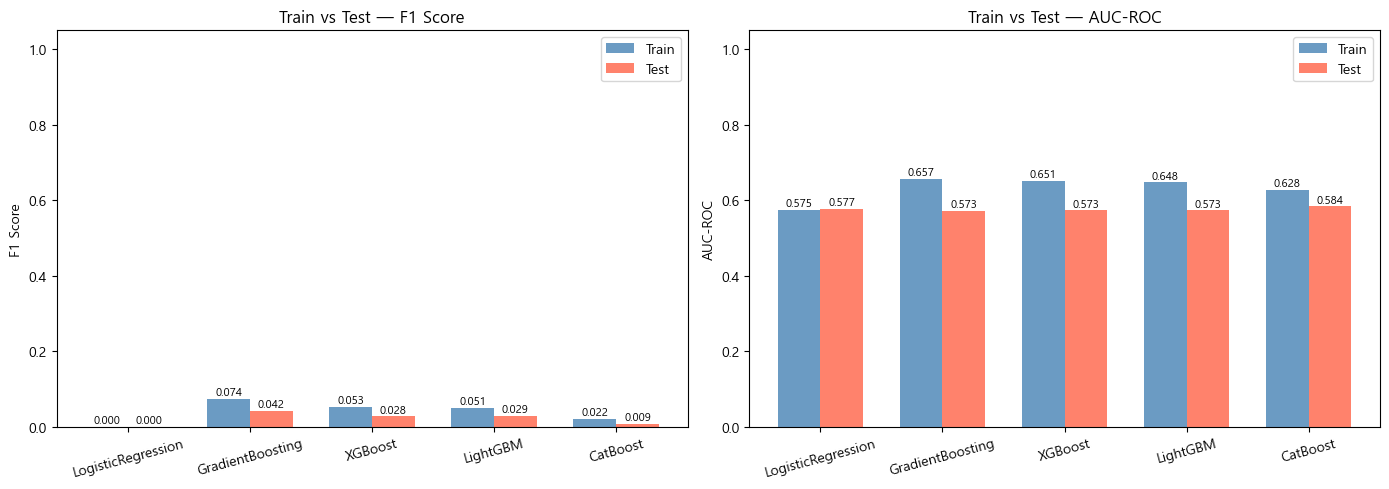

In [47]:
models    = result_df['model'].unique()
f1_train  = result_df[result_df['split'] == 'train'].set_index('model')['f1']
f1_test   = result_df[result_df['split'] == 'test'].set_index('model')['f1']
auc_train = result_df[result_df['split'] == 'train'].set_index('model')['auc']
auc_test  = result_df[result_df['split'] == 'test'].set_index('model')['auc']

x     = np.arange(len(models))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (tr, te, ylabel, title) in zip(axes, [
    (f1_train,  f1_test,  'F1 Score',  'Train vs Test — F1 Score'),
    (auc_train, auc_test, 'AUC-ROC',   'Train vs Test — AUC-ROC'),
]):
    ax.bar(x - width/2, tr[models], width, label='Train', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, te[models], width, label='Test',  color='tomato',    alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1.05)
    for i, (a, b) in enumerate(zip(tr[models], te[models])):
        ax.text(i - width/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=8)
        ax.text(i + width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 5. AUC-ROC 커브 & PR 커브 (Test set)

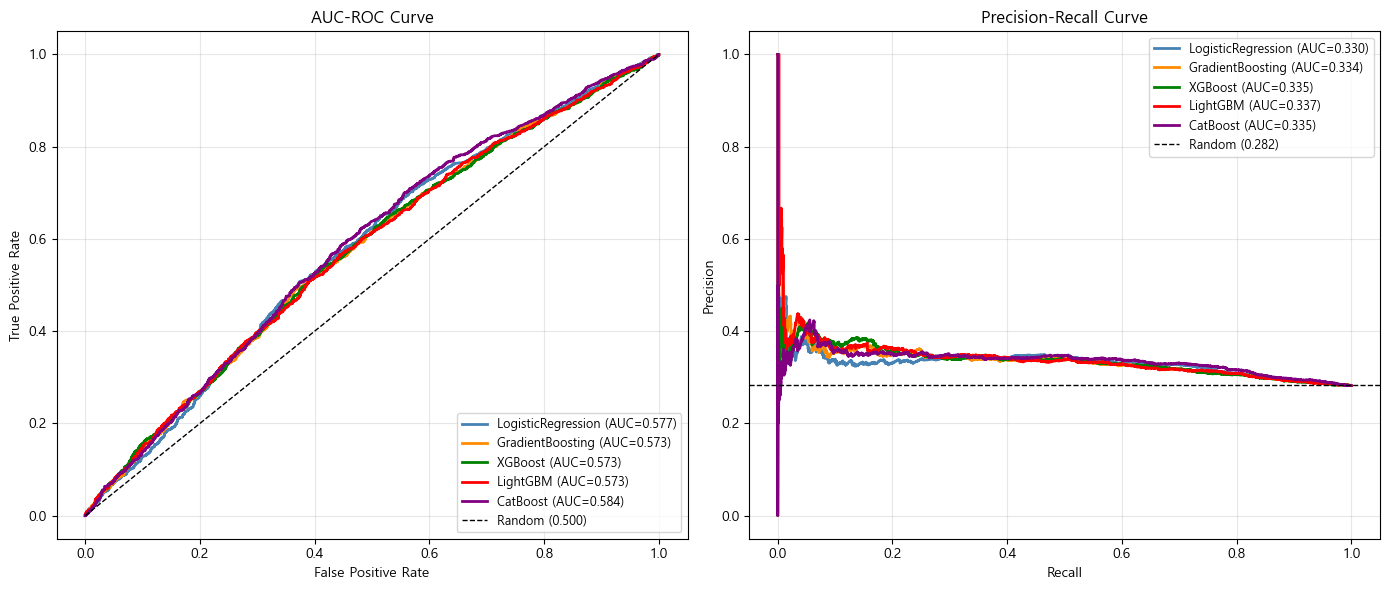

In [48]:
model_probas = {
    'LogisticRegression': lr.predict_proba(X_test_sc)[:, 1],
    'GradientBoosting':   gb.predict_proba(X_test)[:, 1],
    'XGBoost':            xgb_model.predict_proba(X_test)[:, 1],
    'LightGBM':           lgb_model.predict_proba(X_test)[:, 1],
    'CatBoost':           cat_model.predict_proba(X_test)[:, 1],
}
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for (name, proba), color in zip(model_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr, tpr):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('AUC-ROC Curve')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

baseline_precision = y_test.mean()
for (name, proba), color in zip(model_probas.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, color=color, lw=2, label=f'{name} (AUC={auc(recall, precision):.3f})')

axes[1].axhline(y=baseline_precision, color='k', linestyle='--', lw=1,
                label=f'Random ({baseline_precision:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. SHAP 분석

- **Beeswarm**: 각 피처가 예측에 미치는 방향과 크기  
- **Bar plot**: 평균 |SHAP| 기준 피처 중요도  
- 트리 모델 4개 각각 분석 (TreeExplainer 사용)


  GradientBoosting


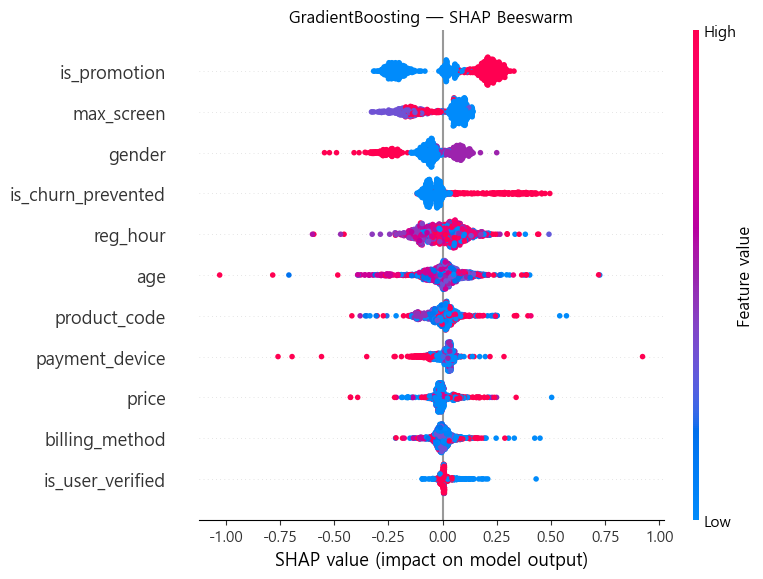

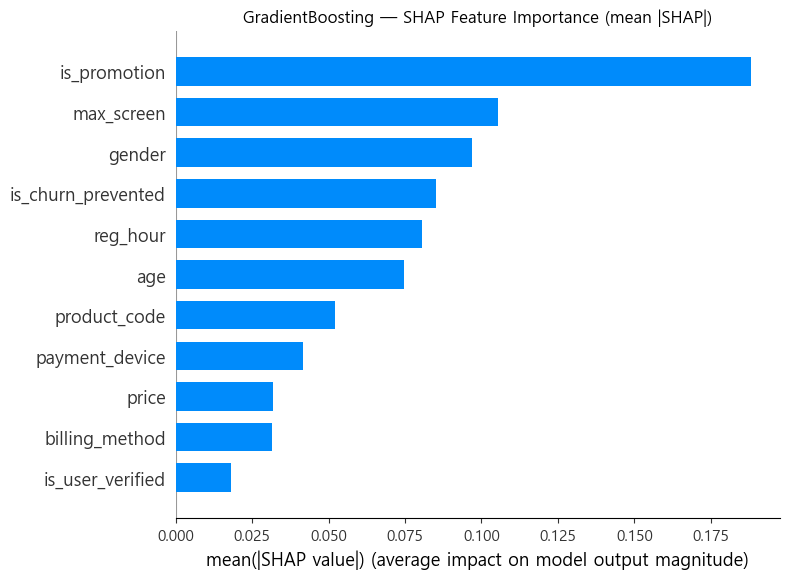


  XGBoost


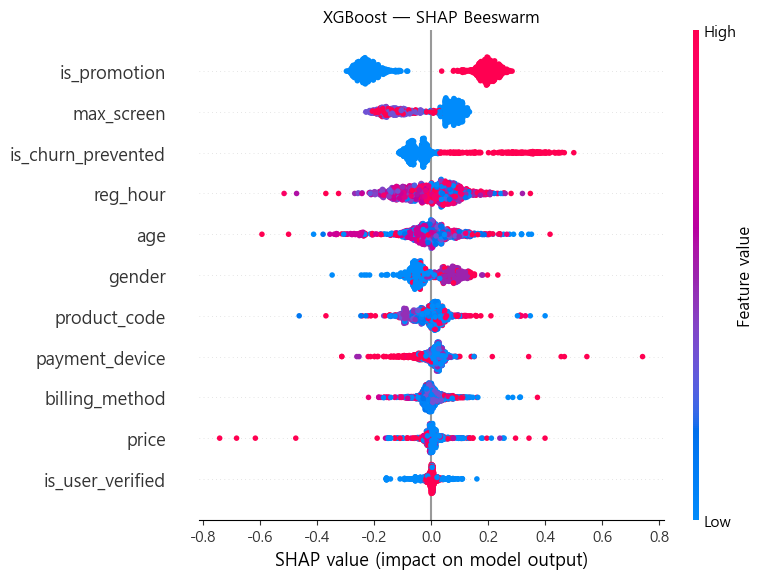

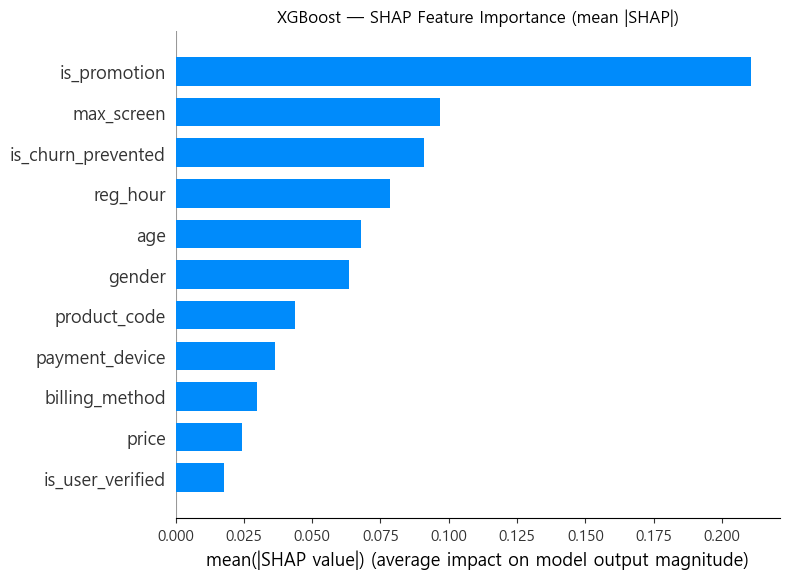


  LightGBM


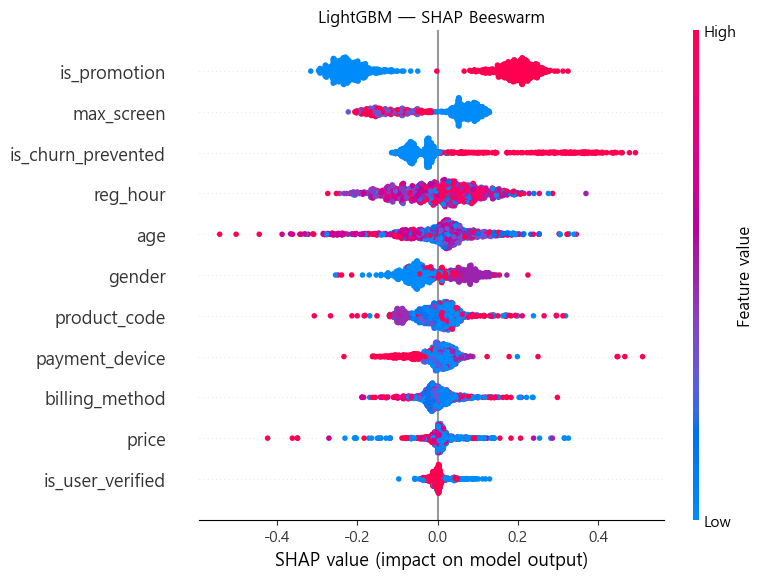

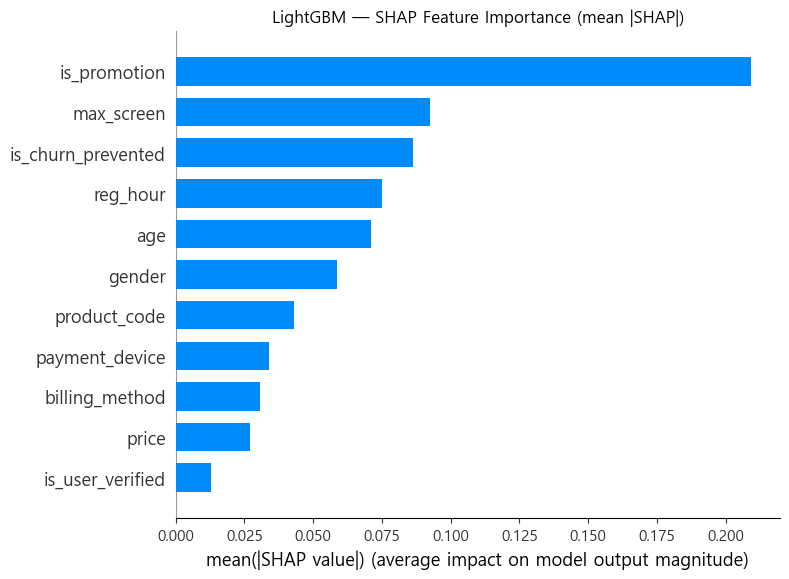


  CatBoost


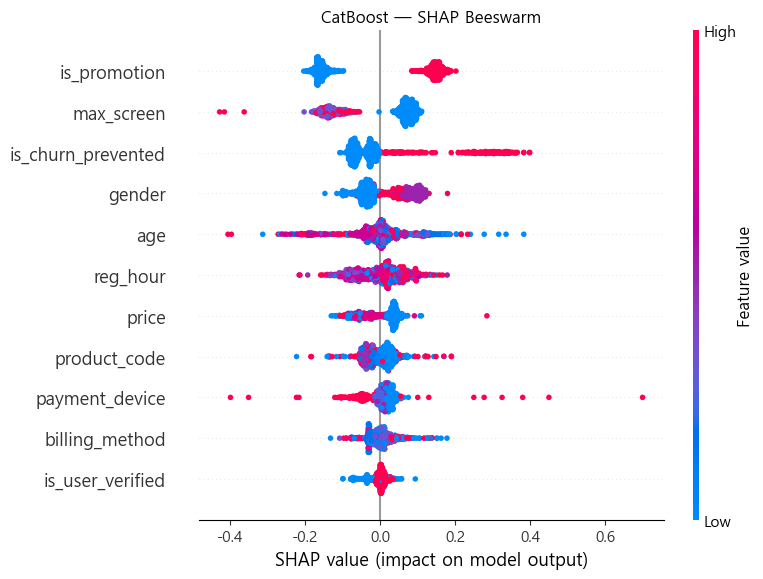

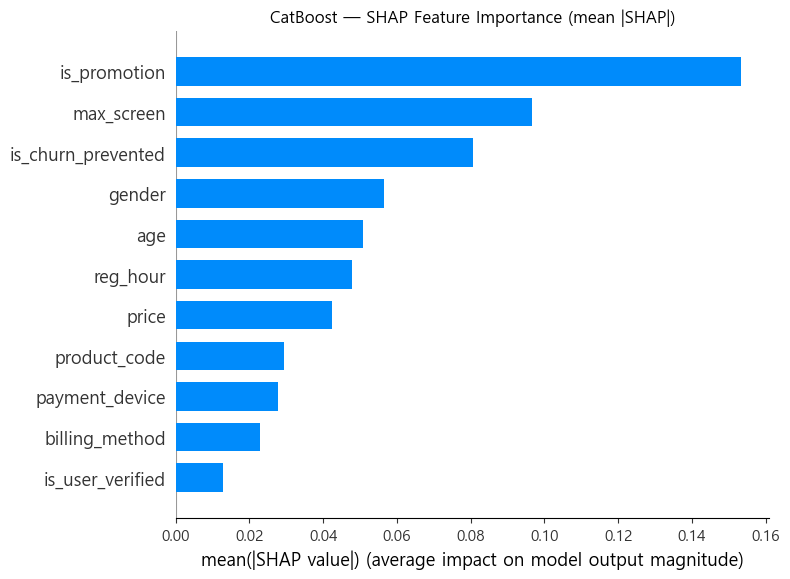

In [50]:
shap.initjs()

tree_models = {
    'GradientBoosting': gb,
    'XGBoost':          xgb_model,
    'LightGBM':         lgb_model,
    'CatBoost':         cat_model,
}

X_shap = X_test.sample(min(1000, len(X_test)), random_state=42)

for name, model in tree_models.items():
    print(f'\n{"="*50}\n  {name}\n{"="*50}')

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    # SHAP 버전별 반환 타입 통일 → numpy array로
    if isinstance(shap_values, list):
        # 구버전: 클래스별 list → class 1(이탈) 선택
        sv = np.array(shap_values[1])
    elif hasattr(shap_values, 'values'):
        # 신버전: Explanation 객체
        vals = shap_values.values
        sv = vals[:, :, 1] if vals.ndim == 3 else vals
    else:
        sv = np.array(shap_values)

    plt.figure()
    shap.summary_plot(sv, X_shap.values, feature_names=list(X_shap.columns),
                      plot_type='dot', show=False)
    plt.title(f'{name} — SHAP Beeswarm')
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(sv, X_shap.values, feature_names=list(X_shap.columns),
                      plot_type='bar', show=False)
    plt.title(f'{name} — SHAP Feature Importance (mean |SHAP|)')
    plt.tight_layout()
    plt.show()

---

## 7. 조인 데이터 모델링 (시청이력 + 영화정보 포함)

**기준**: Membership (유저 1명 = 1행)  
**추가 피처**: View_History·Movie_Master를 유저 단위로 집계한 파생변수 사용  
**3주 필터**: 각 유저의 `reg_date ~ reg_date+21일` 이내 시청 이력만 집계

| 파일 | 역할 |
|---|---|
| `Membership_v2` | 구독 정보 + 타겟 (기준) |
| `User_Mapping_v2` | USER_KEY → USER_NUM 변환 |
| `View_History_v2` | 유저별 시청 이력 집계 |
| `Movie_Master_v2` | 장르별 시청 횟수 집계 |

In [61]:
BASE = '../kim.kwangil/preprocessing/260509_view_delete/'

mem  = pd.read_csv(BASE + 'Membership_v2.csv')
mmap = pd.read_csv(BASE + 'User_Mapping_v2.csv')
vh   = pd.read_csv(BASE + 'View_History_v2.csv')
mm   = pd.read_csv(BASE + 'Movie_Master_v2.csv')

print(f'Membership  : {mem.shape}')
print(f'User_Mapping: {mmap.shape}')
print(f'View_History: {vh.shape}')
print(f'Movie_Master: {mm.shape}')

Membership  : (23343, 15)
User_Mapping: (23720, 2)
View_History: (175301, 5)
Movie_Master: (14502, 4)


In [62]:
# ── Membership: 3주 필터 + 타겟 생성 + obs_cutoff 계산 ──────────────
mem['reg_date'] = pd.to_datetime(mem['reg_date'])
mem['end_date'] = pd.to_datetime(mem['end_date'])

sub_days = (mem['end_date'] - mem['reg_date']).dt.days
mem = mem[sub_days >= 21].copy()
mem['churn'] = 1 - mem['is_repurchase']
mem['obs_cutoff'] = (mem['reg_date'] + pd.Timedelta(days=21)).dt.strftime('%Y%m%d').astype(int)

# USER_KEY → USER_NUM 매핑
mem = mem.merge(mmap, on='USER_KEY', how='left')
print(f'Membership (필터 후): {mem.shape}')

Membership (필터 후): (23181, 18)


In [63]:
# ── View_History: 3주 이내 필터 후 유저 단위 집계 ───────────────────
vh_f = vh.merge(mem[['USER_NUM', 'obs_cutoff']], on='USER_NUM', how='inner')
vh_f = vh_f[vh_f['watch_day'] <= vh_f['obs_cutoff']].copy()

vh_agg = vh_f.groupby('USER_NUM').agg(
    total_watch_time  = ('watch_time(min)', 'sum'),
    total_watch_count = ('watch_time(min)', 'count'),
    unique_movie      = ('MOVIE_NUM',       'nunique'),
    watch_days        = ('watch_day',       'nunique'),
    max_watch_time    = ('watch_time(min)', 'max'),
).reset_index()

vh_agg = vh_agg.rename(columns={
    'total_watch_time': 'total_watch_time(min)',
    'max_watch_time':   'max_watch_time(min)',
})

print(f'유저별 집계 완료: {vh_agg.shape}')
print(f'집계 피처: {vh_agg.columns.tolist()}')

유저별 집계 완료: (21903, 6)
집계 피처: ['USER_NUM', 'total_watch_time(min)', 'total_watch_count', 'unique_movie', 'watch_days', 'max_watch_time(min)']


In [65]:
# ── 최종 데이터셋: Membership(기준) + 집계 피처 조인 ─────────────────
mem_cols = ['USER_NUM', 'product_code', 'price', 'billing_method', 'max_screen',
            'is_promotion', 'is_churn_prevented', 'payment_device',
            'is_user_verified', 'gender', 'age', 'reg_hour', 'churn']

final_df = mem[mem_cols].merge(vh_agg, on='USER_NUM', how='left')

# 시청 이력 없는 유저 → 0
view_cols = [c for c in final_df.columns if c not in mem_cols]
final_df[view_cols] = final_df[view_cols].fillna(0)

print(f'최종 데이터: {final_df.shape}  (유저 1명 = 1행)')
print(f'시청 이력 있는 유저: {(final_df["total_watch_count"] > 0).sum()}명')
print(f'시청 이력 없는 유저: {(final_df["total_watch_count"] == 0).sum()}명')
final_df.head(3)

최종 데이터: (23181, 18)  (유저 1명 = 1행)
시청 이력 있는 유저: 22013명
시청 이력 없는 유저: 1168명


,USER_NUM,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,payment_device,is_user_verified,gender,age,reg_hour,churn,total_watch_time(min),total_watch_count,unique_movie,watch_days,max_watch_time(min)
0,2342,pk_1489,100.0,134,4.0,1,0,pc,1,F,20.0,20,0,518.0,13.0,10.0,9.0,200.0
1,17323,pk_1487,100.0,190,1.0,1,1,pc,1,F,25.0,14,1,4.0,3.0,3.0,2.0,2.0
2,18313,pk_1488,100.0,180,2.0,1,0,android,1,F,20.0,2,1,129.0,2.0,2.0,1.0,128.0


In [66]:
# ── 전처리 및 Train/Test 분리 ────────────────────────────────────────
j_cat_cols = ['product_code', 'payment_device', 'gender']
j_num_cols = [c for c in final_df.columns if c not in j_cat_cols + ['USER_NUM', 'churn']]

j_enc = final_df[j_cat_cols + j_num_cols + ['churn']].copy()
le2 = LabelEncoder()
for col in j_cat_cols:
    j_enc[col] = le2.fit_transform(j_enc[col].astype(str))

Xj = j_enc[j_cat_cols + j_num_cols]
yj = j_enc['churn']

Xj_train, Xj_test, yj_train, yj_test = train_test_split(
    Xj, yj, test_size=0.2, random_state=42, stratify=yj
)

scaler2 = StandardScaler()
Xj_train_sc = scaler2.fit_transform(Xj_train)
Xj_test_sc  = scaler2.transform(Xj_test)

print(f'Train: {Xj_train.shape}, Test: {Xj_test.shape}')
print(f'Train 이탈률: {yj_train.mean():.2%} | Test 이탈률: {yj_test.mean():.2%}')
print(f'\n사용 피처 ({len(j_cat_cols + j_num_cols)}개):')
print(j_cat_cols + j_num_cols)

Train: (18544, 16), Test: (4637, 16)
Train 이탈률: 28.21% | Test 이탈률: 28.21%

사용 피처 (16개):
['product_code', 'payment_device', 'gender', 'price', 'billing_method', 'max_screen', 'is_promotion', 'is_churn_prevented', 'is_user_verified', 'age', 'reg_hour', 'total_watch_time(min)', 'total_watch_count', 'unique_movie', 'watch_days', 'max_watch_time(min)']


In [67]:
# ── 5개 모델 학습 ────────────────────────────────────────────────────
j_results = []

# Logistic Regression
lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(Xj_train_sc, yj_train)
j_results.extend(evaluate('LogisticRegression', lr2, Xj_train_sc, yj_train, Xj_test_sc, yj_test))
print('LogisticRegression 완료')

# Gradient Boosting
gb2 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gb2.fit(Xj_train, yj_train)
j_results.extend(evaluate('GradientBoosting', gb2, Xj_train, yj_train, Xj_test, yj_test))
print('GradientBoosting 완료')

# XGBoost
xgb2 = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                           use_label_encoder=False, eval_metric='logloss',
                           random_state=42, verbosity=0)
xgb2.fit(Xj_train, yj_train)
j_results.extend(evaluate('XGBoost', xgb2, Xj_train, yj_train, Xj_test, yj_test))
print('XGBoost 완료')

# LightGBM
lgb2 = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                            random_state=42, verbose=-1)
lgb2.fit(Xj_train, yj_train)
j_results.extend(evaluate('LightGBM', lgb2, Xj_train, yj_train, Xj_test, yj_test))
print('LightGBM 완료')

# CatBoost
cat2 = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=4,
                           random_seed=42, verbose=0)
cat2.fit(Xj_train, yj_train)
j_results.extend(evaluate('CatBoost', cat2, Xj_train, yj_train, Xj_test, yj_test))
print('CatBoost 완료')

LogisticRegression 완료
GradientBoosting 완료
XGBoost 완료
LightGBM 완료
CatBoost 완료


In [68]:
# ── 성능 비교 (Train vs Test) ────────────────────────────────────────
j_result_df = pd.DataFrame(j_results)

j_pivot = j_result_df.pivot(index='model', columns='split', values=['accuracy', 'f1', 'auc'])
j_pivot.columns = [f'{m}_{s}' for m, s in j_pivot.columns]
j_pivot['f1_gap']  = j_pivot['f1_train']  - j_pivot['f1_test']
j_pivot['auc_gap'] = j_pivot['auc_train'] - j_pivot['auc_test']

print('=== 조인 데이터 모델 — Train vs Test ===')
display(j_pivot.round(4).style.background_gradient(cmap='RdYlGn_r', subset=['f1_gap', 'auc_gap']))

print('\n=== 전체 지표 (Test 기준) ===')
j_test_df = j_result_df[j_result_df['split'] == 'test'].set_index('model')
display(j_test_df[['accuracy', 'precision', 'recall', 'f1', 'auc']].round(4))

=== 조인 데이터 모델 — Train vs Test ===


,accuracy_test,accuracy_train,f1_test,f1_train,auc_test,auc_train,f1_gap,auc_gap
model,,,,,,,,
CatBoost,0.762300,0.760400,0.388500,0.392300,0.734000,0.757900,0.003800,0.023900
GradientBoosting,0.757800,0.774200,0.395300,0.450000,0.728400,0.803800,0.054700,0.075400
LightGBM,0.758700,0.766400,0.392200,0.425100,0.727300,0.796700,0.032900,0.069400
LogisticRegression,0.734700,0.731600,0.289800,0.291900,0.711400,0.708500,0.002100,-0.002900
XGBoost,0.757000,0.767000,0.384500,0.427200,0.729300,0.792600,0.042700,0.063300



=== 전체 지표 (Test 기준) ===


,accuracy,precision,recall,f1,auc
model,,,,,
LogisticRegression,0.7347,0.5920,0.1919,0.2898,0.7114
GradientBoosting,0.7578,0.6685,0.2806,0.3953,0.7284
XGBoost,0.7570,0.6730,0.2691,0.3845,0.7293
LightGBM,0.7587,0.6773,0.2760,0.3922,0.7273
CatBoost,0.7623,0.7085,0.2676,0.3885,0.7340


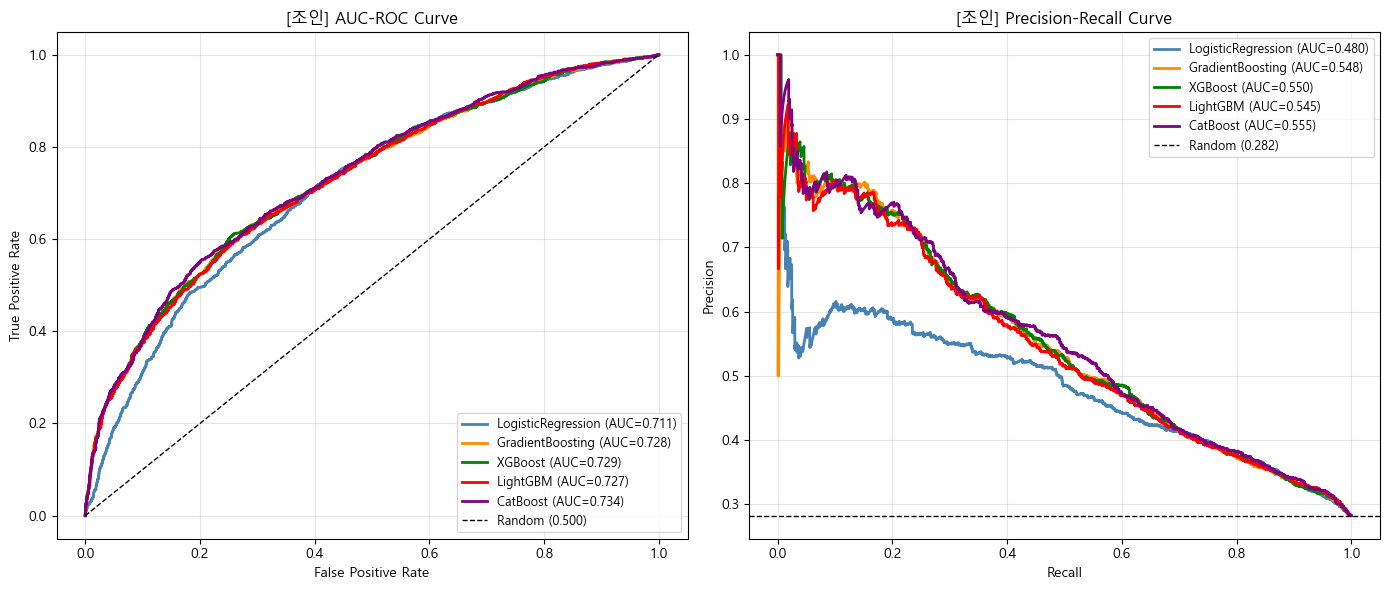

In [69]:
# ── ROC / PR 커브 ────────────────────────────────────────────────────
j_model_probas = {
    'LogisticRegression': lr2.predict_proba(Xj_test_sc)[:, 1],
    'GradientBoosting':   gb2.predict_proba(Xj_test)[:, 1],
    'XGBoost':            xgb2.predict_proba(Xj_test)[:, 1],
    'LightGBM':           lgb2.predict_proba(Xj_test)[:, 1],
    'CatBoost':           cat2.predict_proba(Xj_test)[:, 1],
}
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for (name, proba), color in zip(j_model_probas.items(), colors):
    fpr, tpr, _ = roc_curve(yj_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('[조인] AUC-ROC Curve')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

baseline_p = yj_test.mean()
for (name, proba), color in zip(j_model_probas.items(), colors):
    precision, recall, _ = precision_recall_curve(yj_test, proba)
    axes[1].plot(recall, precision, color=color, lw=2, label=f'{name} (AUC={auc(recall, precision):.3f})')
axes[1].axhline(y=baseline_p, color='k', linestyle='--', lw=1, label=f'Random ({baseline_p:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('[조인] Precision-Recall Curve')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


  GradientBoosting  [조인 데이터]


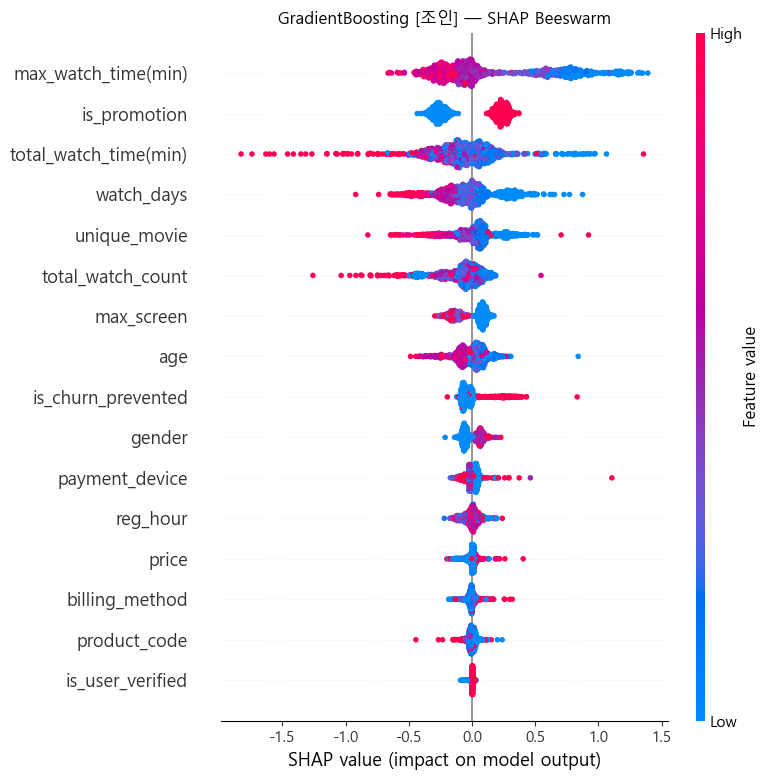

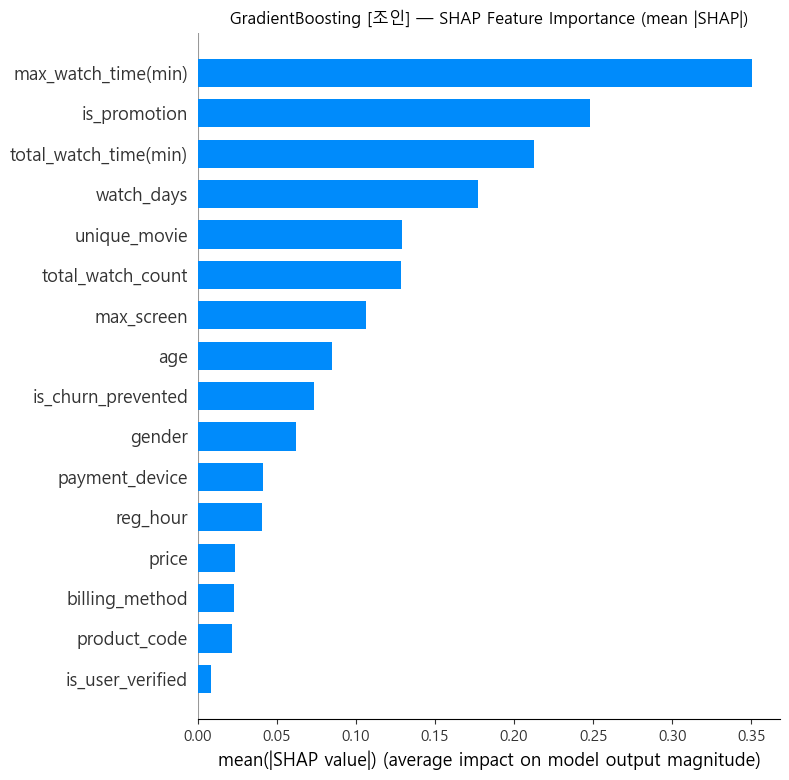


  XGBoost  [조인 데이터]


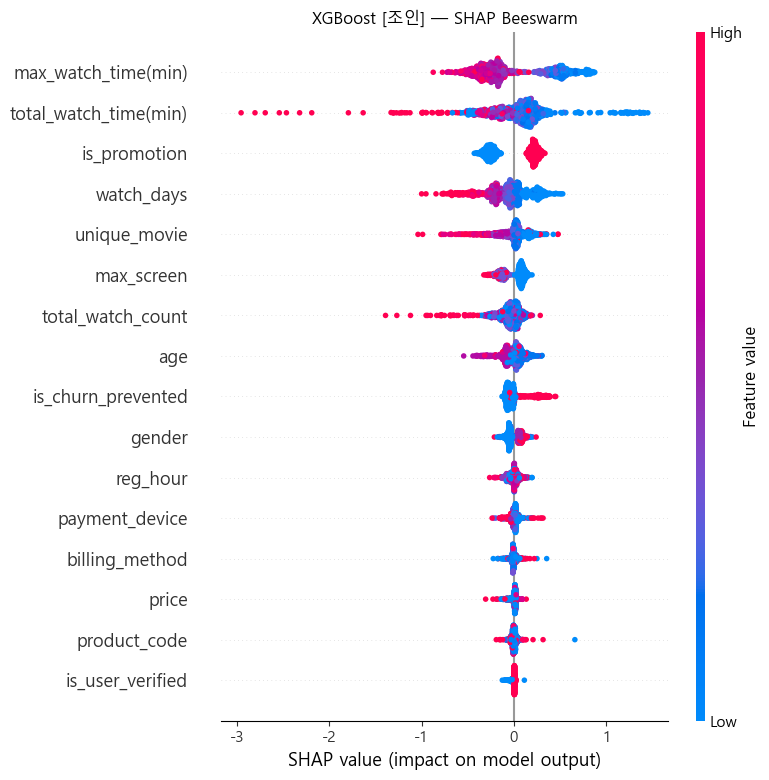

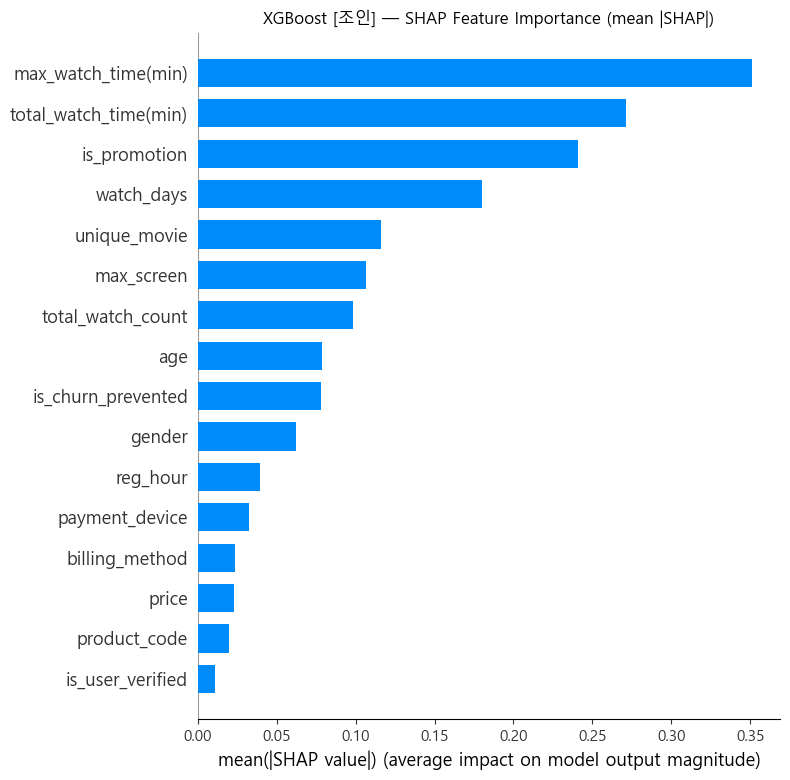


  LightGBM  [조인 데이터]


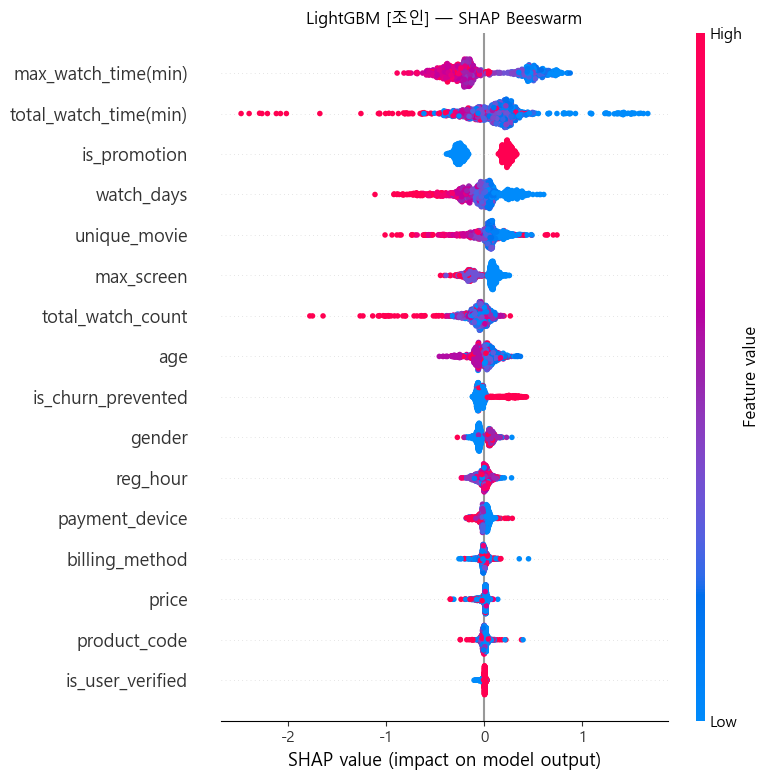

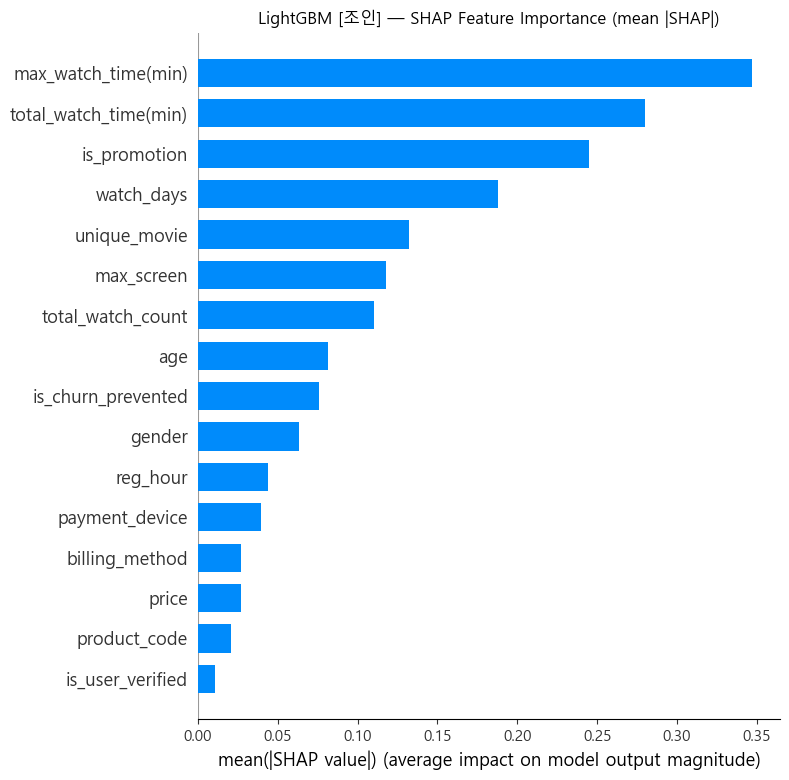


  CatBoost  [조인 데이터]


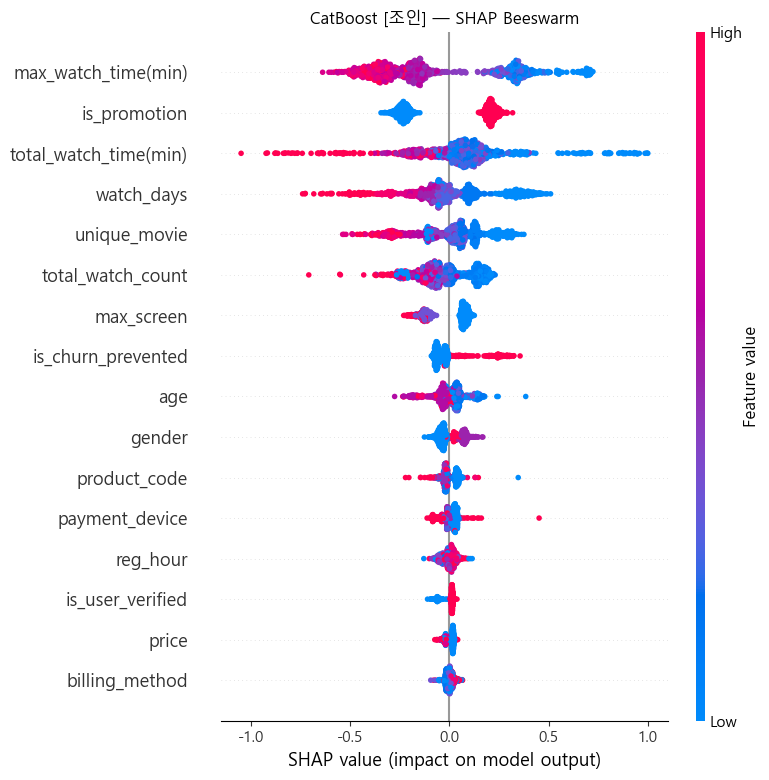

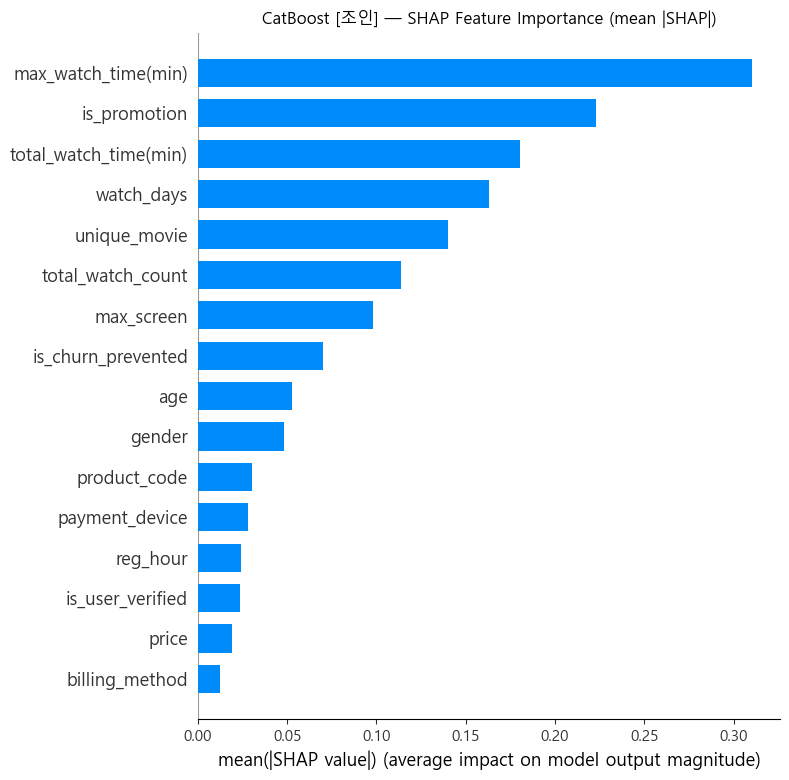

In [70]:
# ── SHAP 분석 (조인 데이터) ──────────────────────────────────────────
j_tree_models = {
    'GradientBoosting': gb2,
    'XGBoost':          xgb2,
    'LightGBM':         lgb2,
    'CatBoost':         cat2,
}

Xj_shap = Xj_test.sample(min(1000, len(Xj_test)), random_state=42)

for name, model in j_tree_models.items():
    print(f'\n{"="*50}\n  {name}  [조인 데이터]\n{"="*50}')

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(Xj_shap)

    if isinstance(shap_values, list):
        sv = np.array(shap_values[1])
    elif hasattr(shap_values, 'values'):
        vals = shap_values.values
        sv = vals[:, :, 1] if vals.ndim == 3 else vals
    else:
        sv = np.array(shap_values)

    plt.figure()
    shap.summary_plot(sv, Xj_shap.values, feature_names=list(Xj_shap.columns),
                      plot_type='dot', show=False)
    plt.title(f'{name} [조인] — SHAP Beeswarm')
    plt.tight_layout()
    plt.show()

    plt.figure()
    shap.summary_plot(sv, Xj_shap.values, feature_names=list(Xj_shap.columns),
                      plot_type='bar', show=False)
    plt.title(f'{name} [조인] — SHAP Feature Importance (mean |SHAP|)')
    plt.tight_layout()
    plt.show()

## 8. 상관관계 & 다중공선성 (VIF)

- **상관관계 히트맵**: 피처 간 선형 관계 시각화
- **VIF (Variance Inflation Factor)**: 다중공선성 수치 확인  
  - VIF < 5: 문제 없음 / VIF 5~10: 주의 / VIF > 10: 다중공선성 의심

### 8-1. 베이스라인 (Membership only)

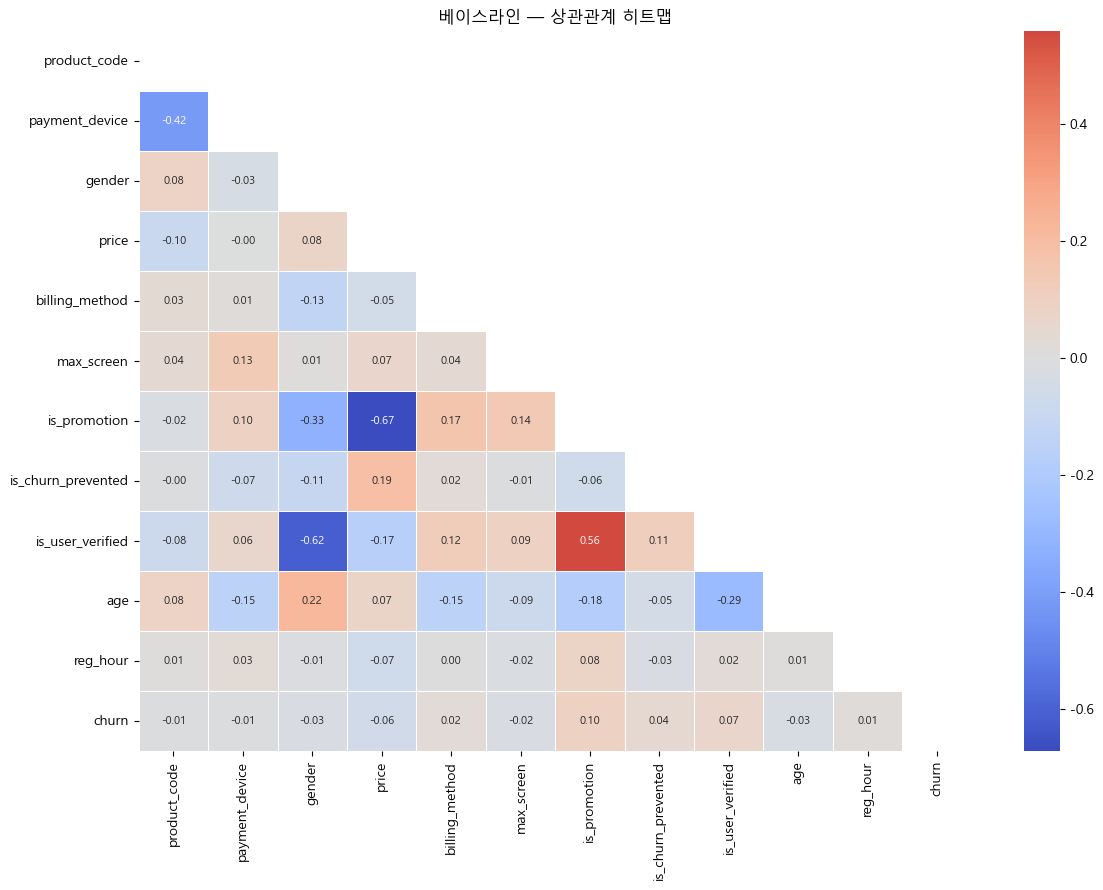

In [71]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── 상관관계 히트맵 (베이스라인) ─────────────────────────────────────
corr_base = X.copy()
corr_base['churn'] = y.values

plt.figure(figsize=(12, 9))
corr_matrix = corr_base.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
import seaborn as sns
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('베이스라인 — 상관관계 히트맵')
plt.tight_layout()
plt.show()

In [76]:
from statsmodels.tools.tools import add_constant

# ── VIF (베이스라인) — 상수항 포함으로 정확한 계산 ───────────────────
X_const = add_constant(X)
vif_base = pd.DataFrame({
    'feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).query('feature != "const"').sort_values('VIF', ascending=False).reset_index(drop=True)

def highlight_vif(val):
    if val > 10:  return 'background-color: #ff4d4d'
    elif val > 5: return 'background-color: #ffcc00'
    return ''

print('베이스라인 — VIF (높을수록 다중공선성 의심)')
display(vif_base.style.map(highlight_vif, subset=['VIF']).format({'VIF': '{:.2f}'}))

베이스라인 — VIF (높을수록 다중공선성 의심)


,feature,VIF
0,is_promotion,3.18
1,is_user_verified,2.33
2,price,2.29
3,gender,1.65
4,payment_device,1.28
5,product_code,1.26
6,age,1.14
7,max_screen,1.12
8,is_churn_prevented,1.07
9,billing_method,1.06


### 8-2. 조인 데이터 (Membership + 시청이력)

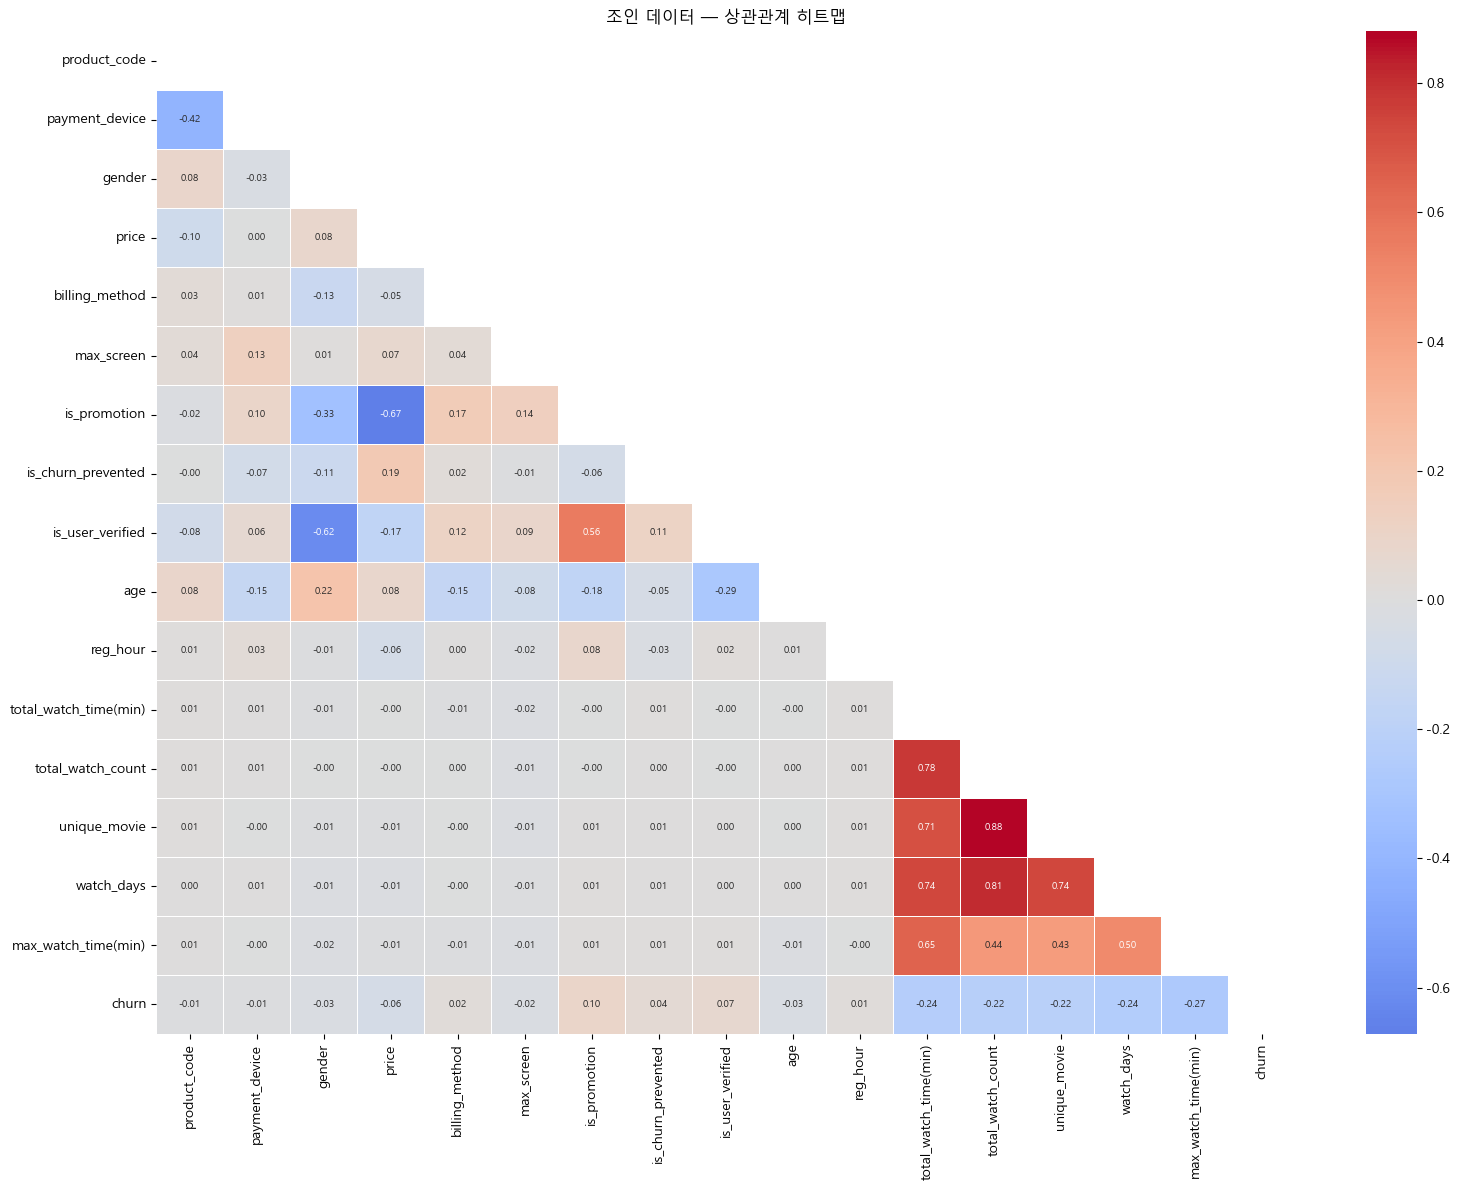

In [77]:
# ── 상관관계 히트맵 (조인 데이터) ───────────────────────────────────
corr_join = Xj.copy()
corr_join['churn'] = yj.values

plt.figure(figsize=(16, 12))
corr_matrix_j = corr_join.corr()
mask_j = np.triu(np.ones_like(corr_matrix_j, dtype=bool))
sns.heatmap(corr_matrix_j, mask=mask_j, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('조인 데이터 — 상관관계 히트맵')
plt.tight_layout()
plt.show()

In [82]:
# ── VIF (조인 데이터) — 상수항 포함으로 정확한 계산 ─────────────────
Xj_const = add_constant(Xj)
vif_join = pd.DataFrame({
    'feature': Xj_const.columns,
    'VIF': [variance_inflation_factor(Xj_const.values, i) for i in range(Xj_const.shape[1])]
}).query('feature != "const"').sort_values('VIF', ascending=False).reset_index(drop=True)

print('조인 데이터 — VIF (높을수록 다중공선성 의심)')
display(vif_join.format({'VIF': '{:.2f}'}))

조인 데이터 — VIF (높을수록 다중공선성 의심)


AttributeError: 'DataFrame' object has no attribute 'format'